# Static and Time-Aware FP8 Quantization for LLaDA-Image


| Component | Details |
|-----------|---------|
| **Goal** | Apply static and time-aware FP8 quantization to [LLaDA-Image](https://huggingface.co/inclusionAI/LLaDA-Image), then compare quality and speed against bf16 and dynamic fp8 |
| **Model** | [inclusionAI/LLaDA-Image](https://huggingface.co/inclusionAI/LLaDA-Image) (bf16 base, 50-step) |
| **Dataset** | [nannullna/laion_subset](https://huggingface.co/datasets/nannullna/laion_subset) (`LAION256`) |
| **Device** | 1xH100 (80GiB) or another NVIDIA GPU with CUDA ≥ 8.9 |
| **Optimization Algorithms** | quantizer(`torchao` fp8dq), quantizer(`static_fp8_diffusers`), quantizer(`time_aware_fp8_diffusers`), compiler(`torch_compile`) |
| **Evaluation Metrics** | `latency`, `clip_score` |

This notebook is a copy of the Flux2 Klein FP8 tutorial, adapted to **LLaDA-Image**.

`LLaDAImagePipeline` subclasses Diffusers' `DiffusionPipeline`, but it is not yet in upstream `diffusers`.
Pruna's FP8 algorithms currently assume an official Diffusers transformer class and a `diffusers` module path.
The **compatibility shims** below register LLaDA's transformer and route inference through `DiffuserHandler`.
`time_aware_fp8_diffusers` already reads the denoising time from `t` or `timestep`.

Use the **bf16 base** checkpoint, not Turbo (too few steps for time-aware calibration) and not `inclusionAI/LLaDA-Image-FP8` (already quantized).

The workflow has two parts.
1. First, we generate a few images from hardcoded prompts and inspect them side by side to confirm that visual quality is preserved.
2. (Extra) We run Pruna's [EvaluationAgent](https://docs.pruna.ai/en/stable/reference/evaluation.html) to measure latency and CLIP score with `torch.compile`.

## Getting Started

Install Pruna, a Diffusers version that matches LLaDA-Image, and clone their inference code.


In [1]:
%pip install pruna
%pip install -U "diffusers>=0.39.0" "transformers>=4.57.0" huggingface_hub


/root/dev/prunatree/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/root/dev/prunatree/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


LLaDA-Image is loaded with `from src import LLaDAImagePipeline`, not `from diffusers import ...`. Clone the official repo once and put it on `sys.path`.


In [2]:
import subprocess
import sys
from pathlib import Path

LLADA_ROOT = Path.home() / ".cache" / "pruna" / "LLaDA-Image"
if not (LLADA_ROOT / "src" / "pipelines" / "pipeline_llada_image.py").is_file():
    LLADA_ROOT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.check_call(
        ["git", "clone", "--depth", "1", "https://github.com/inclusionAI/LLaDA-Image.git", str(LLADA_ROOT)]
    )

sys.path.insert(0, str(LLADA_ROOT))
print(f"LLaDA-Image sources: {LLADA_ROOT}")


LLaDA-Image sources: /root/.cache/pruna/LLaDA-Image


The device is set to the best available option. FP8 kernels need a GPU with compute capability ≥ 8.9. On older hardware the smash step will warn and the quantized matmuls will not run at full speed.


In [3]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    major, minor = torch.cuda.get_device_capability()
    print(f"Compute capability: {major}.{minor}")
    if (major, minor) < (8, 9):
        print("Warning: FP8 quantization requires compute capability ≥ 8.9.")


Using device: cuda
Compute capability: 9.0


Last, import all the necessary modules.


In [4]:
import gc
import inspect

import matplotlib.pyplot as plt
from diffusers.pipelines.pipeline_utils import DiffusionPipeline
from pruna import SmashConfig, smash
from pruna.data.pruna_datamodule import PrunaDataModule
from pruna.engine.model_checks import is_diffusers_model
from pruna.engine.handler.handler_diffuser import DiffuserHandler
from pruna.engine.handler.handler_utils import register_inference_handler as _orig_register_inference_handler
import pruna.engine.handler.handler_utils as handler_utils
import pruna.engine.pruna_model as pruna_model_module
from pruna.engine.utils import safe_memory_cleanup
from src.models import LLaDAImageTransformer2DModel
from src.pipelines.pipeline_llada_image import LLaDAImagePipeline


/root/dev/prunatree/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.12.1+cu130 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


## Compatibility shims (notebook-only)

These two patches are still notebook-only:

1. Register `LLaDAImageTransformer2DModel` on `diffusers.models.transformers` so `is_diffusers_model` and `torchao` recognize the denoiser.
2. Route any `DiffusionPipeline` to `DiffuserHandler`. LLaDA's class lives in `src.pipelines...`, so the default `"diffusers" in __module__` check would pick `StandardHandler` and break calibration.

Quantize **only** `transformer.*`. The LLaDA2 text encoder, QueryFormer, text projection, and SigVQ stay in bf16.
Exclude `sigvq_refiner`: that branch runs only for image editing, so text-to-image calibration never visits it.


In [5]:
import diffusers.models.transformers as diffusers_transformers

diffusers_transformers.LLaDAImageTransformer2DModel = LLaDAImageTransformer2DModel

QUANTIZER_TARGET_MODULES = {
    "include": ["transformer.*"],
    "exclude": ["*embed*", "*norm*", "proj_out", "*sigvq_refiner*"],
}


def _register_inference_handler(model, smash_config):
    unwrapped = model._orig_mod if hasattr(model, "_orig_mod") else model
    if isinstance(unwrapped, DiffusionPipeline):
        return DiffuserHandler(call_signature=inspect.signature(unwrapped.__call__))
    return _orig_register_inference_handler(model, smash_config)


handler_utils.register_inference_handler = _register_inference_handler
pruna_model_module.register_inference_handler = _register_inference_handler

print("LLaDA-Image Pruna shims installed.")
print("Registered transformer:", hasattr(diffusers_transformers, "LLaDAImageTransformer2DModel"))


LLaDA-Image Pruna shims installed.
Registered transformer: True


## 1. Load the Model

Weights are public. The LLaDA2 text encoder is loaded with `trust_remote_code=True` inside `LLaDAImagePipeline.from_pretrained`.


In [6]:
MODEL_ID = "inclusionAI/LLaDA-Image"


def load_pipeline():
    """Load a fresh pipeline from the local Hugging Face cache."""
    pipe = LLaDAImagePipeline.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, device=device)
    pipe.set_progress_bar_config(disable=True)
    return pipe


def release_memory():
    gc.collect()
    safe_memory_cleanup()


print("Loading LLaDA-Image pipeline...")
pipe = load_pipeline()
print("Pipeline class:", type(pipe).__name__)
print("Transformer class:", type(pipe.transformer).__name__)
print("is_diffusers_model:", is_diffusers_model(pipe))
print("Pipeline loaded!")


Loading LLaDA-Image pipeline...


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 241.67it/s]


Pipeline class: LLaDAImagePipeline
Transformer class: LLaDAImageTransformer2DModel
is_diffusers_model: True
Pipeline loaded!


## 2. Define Generation Parameters

Keep the same parameters for every variant to ensure fair comparison.

Do **not** pass `image` in text-to-image mode — LLaDA rejects it unless `generation_mode="editing"`.
`generation_mode` defaults to `"text"`.

We **do not** enable `torch.compile` for the visual check. Compilation reveals the true speedup an algorithm brings, but requires slower warmup generations.


In [7]:
PROMPT = (
    "A cinematic photograph of a red fox standing in fresh snow, "
    "soft winter light, detailed fur, shallow depth of field"
)
NEGATIVE_PROMPT  = ""
PROMPTS = [(PROMPT, NEGATIVE_PROMPT)]

gen_kwargs = dict(
    height=1024,
    width=1024,
    guidance_scale=4.5,
    num_inference_steps=50,
)

SEED = 42


def get_generator():
    return torch.Generator(device=device).manual_seed(SEED)


def generate_image(model, prompt: tuple[str, str]):
    return model(
        prompt=prompt[0],
        negative_prompt=prompt[1],
        generator=get_generator(),
        **gen_kwargs,
    ).images[0]


## 3. Configure the Calibration Data

The static algorithms, `static_fp8_diffusers` and `time_aware_fp8_diffusers`, both freeze activation scales following calibration comprising few complete noise-to-image generations.

Attach a dataset to the `SmashConfig` with `add_data`. Pruna ships several image-generation datasets for which a single keyword is enough. We use `LAION256`. Other built-in keywords that work for this task include `COCO`, `DrawBench`, and `PartiPrompts`. Check [Configure Datasets](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/configure.html#configure-datasets) and [Customize Datasets](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/customize_dataset.html) to learn how to provide a custom dataset.

The validation split is used for calibration and `calibration_batches` generations are run.

```python
smash_config = SmashConfig({"static_fp8_diffusers": {"calibration_batches": 4}})
smash_config.add_data("LAION256")
```


In [8]:
CALIBRATION_BATCHES = 2  # lower this to speed up calibration
CALIBRATION_DATASET = "LAION256"


def attach_calibration_data(smash_config: SmashConfig) -> SmashConfig:
    smash_config.add_data(CALIBRATION_DATASET)
    smash_config.data.limit_datasets(16)
    return smash_config


## 4. Configure the Quantization Algorithms

All four variants quantize linear layers in the **DiT only** (`transformer.*`). Embeddings, norms, and `proj_out` stay in bf16.

### Dynamic

`torchao` with `quant_type="fp8dq"` quantizes weights statically and **recomputes** an activation scale on every forward. That makes it the simplest FP8 baseline - no calibration dataset, and the scale always matches the current tensor. The extra `amax` computation on every layer and step is the cost you pay at inference.

### Static FP8

`static_fp8_diffusers` quantizes weights statically. Activation scales are gathered over a few full denoising trajectories, then **frozen to one scale per layer**. At inference the layer uses the fixed scale, so there is no per-forward `amax`.

### Time-aware FP8

`time_aware_fp8_diffusers` quantizes the weights statically. Activation statistics are stored **per denoising timestep** and looked up at inference. This follows the observation that input distributions shift across the noise schedule ([Temporal Dynamic Quantization](https://arxiv.org/abs/2306.02316)).


In [9]:
def make_smash_config(configuration: dict) -> SmashConfig:
    smash_config = SmashConfig(configuration)
    # Disable saving to avoid writing a full pipeline copy to disk.
    smash_config.disable_saving()
    return smash_config


def smash_dynamic_fp8(model):
    smash_config = make_smash_config(
        {"torchao": {"quant_type": "fp8dq", "target_modules": QUANTIZER_TARGET_MODULES}}
    )
    return smash(model=model, smash_config=smash_config)


def smash_static_fp8(model):
    smash_config = make_smash_config(
        {
            "static_fp8_diffusers": {
                "calibration_batches": CALIBRATION_BATCHES,
                "target_modules": QUANTIZER_TARGET_MODULES,
            }
        }
    )
    attach_calibration_data(smash_config)
    return smash(model=model, smash_config=smash_config)


def smash_time_aware_fp8(model):
    smash_config = make_smash_config(
        {
            "time_aware_fp8_diffusers": {
                "calibration_batches": CALIBRATION_BATCHES,
                "calibration_num_inference_steps": gen_kwargs["num_inference_steps"],
                "target_modules": QUANTIZER_TARGET_MODULES,
            }
        }
    )
    attach_calibration_data(smash_config)
    return smash(model=model, smash_config=smash_config)


quant_builders = [
    ("TorchAO FP8-DQ", smash_dynamic_fp8),
    ("Static FP8", smash_static_fp8),
    ("Time-aware FP8", smash_time_aware_fp8),
]


## 5. Smash and Compare Images

We smash a freshly loaded pipeline\* using each quantization algorithm and generate image(s) with the hardcoded prompt(s).

\*Reloading with `from_pretrained` uses the local Hugging Face cache, so later loads do not re-download the weights.


In [10]:
images_by_prompt = {prompt: [] for prompt in PROMPTS}

print("--- BF16 baseline ---")
for prompt in PROMPTS:
    images_by_prompt[prompt].append(generate_image(pipe, prompt))
del pipe
release_memory()

for name, builder in quant_builders:
    print(f"--- {name} ---")
    quantized = builder(load_pipeline())
    for prompt in PROMPTS:
        images_by_prompt[prompt].append(generate_image(quantized, prompt))
    del quantized
    release_memory()

print("Visual generations complete.")


--- BF16 baseline ---
--- TorchAO FP8-DQ ---


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 234.18it/s]
INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
WARNING - torchao has strict version compatibility requirements with torch. If you encounter crashes when using torchao, ensure that your torch and torchao versions are compatible, as documented in the torchao compatibility table: https://github.com/pytorch/ao/issues/2919#issue-3375688762
INFO - Determined algorithm order: torchao
INFO - Starting torchao...
INFO - torchao was applied successfully.


--- Static FP8 ---


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 238.65it/s]
INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Testing compatibility with image_generation_collate...
INFO - Determined algorithm order: static_fp8_diffusers
INFO - Starting static_fp8_diffusers...
INFO - Using best available device: 'cuda'
INFO - static_fp8_diffusers calibrated over 2 batch(es).
INFO - static_fp8_diffusers was applied successfully.


--- Time-aware FP8 ---


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 233.73it/s]
INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Testing compatibility with image_generation_collate...
INFO - Determined algorithm order: time_aware_fp8_diffusers
INFO - Starting time_aware_fp8_diffusers...
INFO - Using best available device: 'cuda'
INFO - Bin edges: tensor([0.0742, 0.1121, 0.1465, 0.1787, 0.2090, 0.2378, 0.2666, 0.2939, 0.3203,
        0.3467, 0.3711, 0.3945, 0.4180, 0.4414, 0.4648, 0.4873, 0.5088, 0.5293,
        0.5508, 0.5723, 0.5918, 0.6113, 0.6309, 0.6504, 0.6699, 0.6875, 0.7051,
        0.7227, 0.7402, 0.7578, 0.7734, 0.7891, 0.8047, 0.8203, 0.8359, 0.8516,
        0.8652, 0.8789, 0.8926, 0.9043, 0.9180, 0.9316, 0.9434, 0.9531, 0.9629,
        0.9746, 0.9844, 0.9922, 0.9980], device='cuda:0')
INFO - time_aware_fp8_diffuse

Visual generations complete.


The four images should remain close in subject, composition, and prompt alignment. However, they will not be identical. Round-to-nearest symmetric quantization does not optimize _reproducing_ the sampler trajectory. Thus, it is an appropriate method for quality-preservation, but it might not be the best for fidelity.


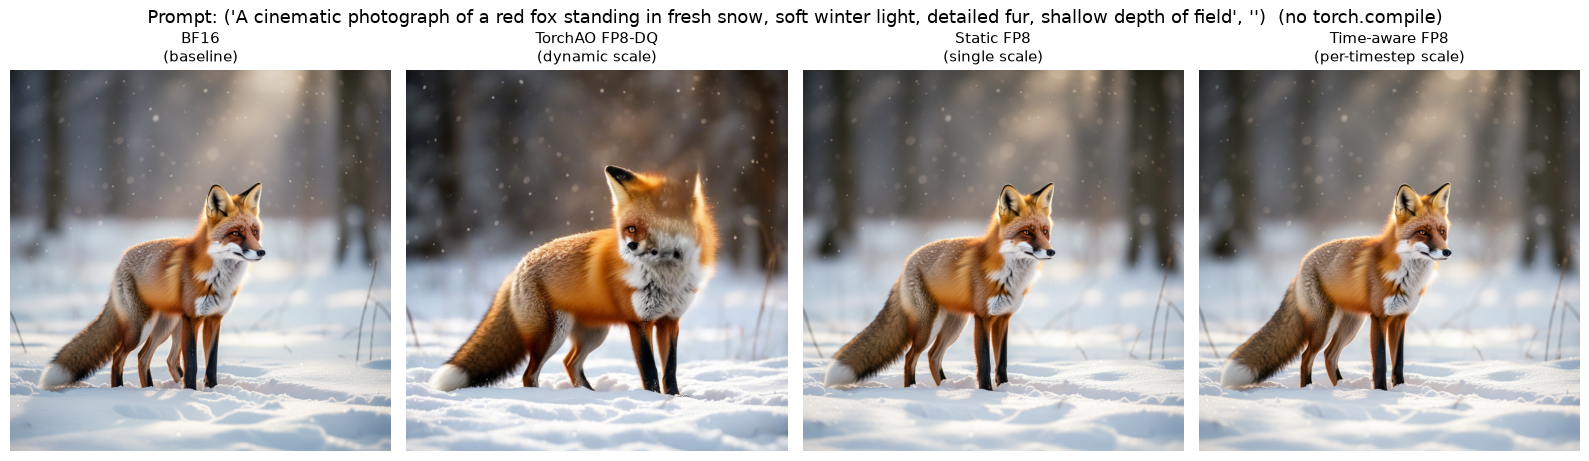

In [11]:
VARIANT_LABELS = [
    "BF16\n(baseline)",
    "TorchAO FP8-DQ\n(dynamic scale)",
    "Static FP8\n(single scale)",
    "Time-aware FP8\n(per-timestep scale)",
]

n_prompts = len(PROMPTS)
fig, axes = plt.subplots(n_prompts, 4, figsize=(16, 4.5 * n_prompts))
if n_prompts == 1:
    axes = [axes]

for row, prompt in enumerate(PROMPTS):
    for col, (image, title) in enumerate(zip(images_by_prompt[prompt], VARIANT_LABELS)):
        axes[row][col].imshow(image)
        axes[row][col].set_title(title, fontsize=11)
        axes[row][col].axis("off")

title = f'Prompt: {PROMPTS[0]}' if n_prompts == 1 else "FP8 variants vs bf16"
plt.suptitle(f"{title}  (no torch.compile)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. Cleanup


In [12]:
del images_by_prompt
release_memory()


## Conclusion

In this notebook we applied Pruna's static and time-aware FP8 quantizers to LLaDA-Image.
`time_aware_fp8_diffusers` reads the denoising time from `t` or `timestep`.
LLaDA's `sigvq_refiner` is excluded because it only runs in editing mode; unvisited targeted Linears fail smash rather than silently skipping quantization.
The remaining notebook shims are the changes still worth making in Pruna:

1. Treat third-party `DiffusionPipeline` subclasses with a DiT as eligible for `static_fp8_diffusers` / `time_aware_fp8_diffusers` / `torchao`.
2. Select `DiffuserHandler` from `isinstance(model, DiffusionPipeline)`, not from the module name.

You can adapt the `SmashConfig`, calibration set, and prompts, or reach out on [Discord](https://discord.gg/JFQmtFKCjd) for questions.


## (Extra) Evaluate with the EvaluationAgent

_This evaluation takes more time — compile warmup plus 50-step generations._

This stage smashes each variant with `torch.compile` to reveal the true speed up each algorithm brings.

We use `torch_compile_mode="max-autotune-no-cudagraphs"`, which is the recommended mode for TorchAO FP8. The first few evaluation batches include compile warmup. `LatencyMetric`'s `n_warmup_iterations` discards them so the reported latency is the steady-state number.

Metrics:

- **`latency`** — average time per batch
- **`clip_score`** — CLIP prompt–image alignment (quality proxy)

The evaluation dataset is `LAION256`. Increase `limit_datasets` and `n_iterations` for a more stable measurement.


In [14]:
from pruna.evaluation.evaluation_agent import EvaluationAgent
from pruna.evaluation.metrics import LatencyMetric, TorchMetricWrapper
from pruna.evaluation.task import Task

COMPILE_KWARGS = {"mode": "default"}
EVAL_INFERENCE_ARGS = {
    "height": gen_kwargs["height"],
    "width": gen_kwargs["width"],
    "guidance_scale": gen_kwargs["guidance_scale"],
    "num_inference_steps": gen_kwargs["num_inference_steps"],
}

eval_datamodule = PrunaDataModule.from_string("LAION256")
eval_datamodule.limit_datasets(8)

metrics = [
    LatencyMetric(n_iterations=5, n_warmup_iterations=2),
    TorchMetricWrapper("clip_score"),
]
task = Task(metrics, datamodule=eval_datamodule, device=device)
eval_agent = EvaluationAgent(task)


def smash_and_evaluate(label: str, configuration: dict, needs_calibration: bool = False):
    print(f"\n=== Evaluating {label} ===")
    smash_config = make_smash_config(configuration)
    if needs_calibration:
        attach_calibration_data(smash_config)
    model = smash(model=load_pipeline(), smash_config=smash_config)
    model.inference_handler.model_args.update(EVAL_INFERENCE_ARGS)
    results = eval_agent.evaluate(model)
    del model
    release_memory()
    return results


results_by_variant = {}
results_by_variant["bf16"] = smash_and_evaluate(
    "bf16",
    {}
)
results_by_variant["fp8dq"] = smash_and_evaluate(
    "torchao fp8dq",
    {
        "torchao": {"quant_type": "fp8dq", "target_modules": QUANTIZER_TARGET_MODULES},
    },
)
results_by_variant["static"] = smash_and_evaluate(
    "static_fp8_diffusers",
    {
        "static_fp8_diffusers": {
            "calibration_batches": CALIBRATION_BATCHES,
            "target_modules": QUANTIZER_TARGET_MODULES,
        },
    },
    needs_calibration=True,
)
results_by_variant["time-aware"] = smash_and_evaluate(
    "time_aware_fp8_diffusers",
    {
        "time_aware_fp8_diffusers": {
            "calibration_batches": CALIBRATION_BATCHES,
            "calibration_num_inference_steps": gen_kwargs["num_inference_steps"],
            "target_modules": QUANTIZER_TARGET_MODULES,
        },
    },
    needs_calibration=True,
)


INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Testing compatibility with image_generation_collate...
INFO - Using best available device: 'cuda'
INFO - Using best available device: 'cuda'
INFO - Using call_type: y_x for metric clip_score
INFO - Using provided list of metric instances.



=== Evaluating bf16 ===


INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 230.96it/s]
INFO - Determined algorithm order: 
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected diffusers model. Using DiffuserHandler with fixed seed.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .images attribute.
INFO - Evaluating stateful metrics.
Processing batches: 100%|██████████| 8/8 [03:20<00:00, 25.01s/batch]
INFO - Evaluating isolated inference metrics.
Measuring inference time: 100%|██████████| 5/5 [02:03<00:00, 24.63s/iter]
INFO - Evaluation run has finished. Moved model to cuda:0



=== Evaluating torchao fp8dq ===


INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 236.97it/s]
WARNING - torchao has strict version compatibility requirements with torch. If you encounter crashes when using torchao, ensure that your torch and torchao versions are compatible, as documented in the torchao compatibility table: https://github.com/pytorch/ao/issues/2919#issue-3375688762
INFO - Determined algorithm order: torchao
INFO - Starting torchao...
INFO - torchao was applied successfully.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected diffusers model. Using DiffuserHandler with fixed seed.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .images attribute.
INFO - Evaluating stateful metrics.
Processing batches: 100%|██████████| 8/8 [03:50<00:00, 28.85s/batch]
INFO - Evaluating isolated inf


=== Evaluating static_fp8_diffusers ===


INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Testing compatibility with image_generation_collate...
Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 238.97it/s]
INFO - Determined algorithm order: static_fp8_diffusers
INFO - Starting static_fp8_diffusers...
INFO - Using best available device: 'cuda'
INFO - static_fp8_diffusers calibrated over 2 batch(es).
INFO - static_fp8_diffusers was applied successfully.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected diffusers model. Using DiffuserHandler with fixed seed.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .images attribute.
INFO - Evaluating stateful metrics.
Processing batches: 100%|██████████| 8/8 [03:08<00:00, 23.62s/batch]
INFO - Evaluating isolated inf


=== Evaluating time_aware_fp8_diffusers ===


INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Testing compatibility with image_generation_collate...
Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 236.48it/s]
INFO - Determined algorithm order: time_aware_fp8_diffusers
INFO - Starting time_aware_fp8_diffusers...
INFO - Using best available device: 'cuda'
INFO - Bin edges: tensor([0.0742, 0.1121, 0.1465, 0.1787, 0.2090, 0.2378, 0.2666, 0.2939, 0.3203,
        0.3467, 0.3711, 0.3945, 0.4180, 0.4414, 0.4648, 0.4873, 0.5088, 0.5293,
        0.5508, 0.5723, 0.5918, 0.6113, 0.6309, 0.6504, 0.6699, 0.6875, 0.7051,
        0.7227, 0.7402, 0.7578, 0.7734, 0.7891, 0.8047, 0.8203, 0.8359, 0.8516,
        0.8652, 0.8789, 0.8926, 0.9043, 0.9180, 0.9316, 0.9434, 0.9531, 0.9629,
        0.9746, 0.9844, 0.9922, 0.9980], device='cuda:0')
INFO - time_aware_fp8_diffuse

We can now review latency and CLIP score across the four compiled models. Lower latency is better. Higher CLIP score is better. We expect the compiled FP8 variants to improve latency, with CLIP scores remaining in the same range. Dynamic FP8 spends extra time on per-forward scales, while static and time-aware avoid that cost post-calibration. If CLIP drops sharply, try more `calibration_batches`, a calibration set closer to your prompts, or leave sensitive modules out via `target_modules`.


In [15]:
from IPython.display import Markdown, display  # noqa

DISPLAY_NAMES = {
    "bf16": "BF16",
    "fp8dq": "TorchAO FP8-DQ",
    "static": "Static FP8",
    "time-aware": "Time-aware FP8",
}


def make_comparison_table(named_results):  # noqa
    names = list(named_results.keys())
    header = "| Metric | " + " | ".join(DISPLAY_NAMES[n] for n in names) + " |\n"
    header += "|" + "-----|" * (len(names) + 1) + "\n"
    first = named_results[names[0]]
    rows = []
    for i, metric in enumerate(first):
        cells = [metric.name]
        for name in names:
            result = named_results[name][i]
            units = f" {result.metric_units}" if result.metric_units else ""
            cells.append(f"{result.result:.4f}{units}")
        rows.append("| " + " | ".join(cells) + " |")
    return header + "\n".join(rows)


display(Markdown(make_comparison_table(results_by_variant)))


| Metric | BF16 | TorchAO FP8-DQ | Static FP8 | Time-aware FP8 |
|-----|-----|-----|-----|-----|
| clip_score | 23.2435 | 23.7787 | 23.3692 | 24.9489 |
| latency | 24620.6178 | 28437.4326 | 23251.3151 | 23252.8460 |